# Regularizacion: Ridge y Lasso - SOLUCIONARIO
## Laboratorio resuelto para ML1 (Tema 11)

**Universidad Externado de Colombia**
**Curso:** Machine Learning I (ML1-2026I)
**Docente:** Julian Zuluaga
**Duracion estimada:** 90 minutos en clase

---

## Que es esta version

Esta es la **version resuelta** del laboratorio de regularizacion. Todo el codigo
esta completo y ejecutado. Despues de cada bloque encuentras una **interpretacion**
de los resultados.

Para la version sin solucion (con TODOs) que entregas a los estudiantes, ver:
`nb-14-guia-regularizacion-diabetes.ipynb`.

## Objetivo del laboratorio

Construir intuicion practica sobre como y **por que** la regularizacion funciona,
partiendo de un caso donde el sobreajuste es **inevitable** y comparando OLS, Ridge y Lasso.

## Estructura

1. **Carga y exploracion** del dataset Diabetes (sklearn)
2. **Linea base honesta:** OLS con 10 features originales (debe generalizar)
3. **Forzar overfitting:** expandir a 285 features con `PolynomialFeatures(degree=3)`
4. **Ridge al rescate** + visualizacion del regularization path
5. **Lasso** + seleccion automatica de features
6. **Comparacion final** y discusion


---

## 0. Setup del entorno

### Sobre el dataset

Usaremos el **dataset Diabetes** que viene incluido en scikit-learn.
**No requiere descarga manual** - sklearn lo trae embebido.

**Origen:** Efron, Hastie, Johnstone & Tibshirani (2004) - paper "Least Angle Regression".

**Caracteristicas:**

- 442 pacientes con diabetes
- 10 mediciones clinicas como features (ya estandarizadas por sklearn)
- Target: medida cuantitativa de progresion de la enfermedad un anyo despues
- Documentacion: https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset

**Variables:**

| Variable | Significado |
|----------|-------------|
| `age`    | edad |
| `sex`    | sexo (codificado) |
| `bmi`    | indice de masa corporal |
| `bp`     | presion arterial promedio |
| `s1`-`s6`| 6 mediciones bioquimicas en suero |


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Estetica
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print('Entorno listo')


Entorno listo


---

## 1. Carga y exploracion

### 1.1 Cargar el dataset


In [2]:
data = load_diabetes()
X = data.data
y = data.target
feature_names = data.feature_names

print(f"Forma de X:     {X.shape}")
print(f"Forma de y:     {y.shape}")
print(f"Features:       {feature_names}")
print(f"\nRatio n/p inicial: {X.shape[0] / X.shape[1]:.1f}  (442 / 10)")


Forma de X:     (442, 10)
Forma de y:     (442,)
Features:       ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Ratio n/p inicial: 44.2  (442 / 10)


**Interpretacion 1.1:**

- `X` tiene **442 filas (pacientes) y 10 columnas (features)** - matriz `(n, p)` con `n=442`, `p=10`.
- `y` es un vector con **442 valores numericos** (la progresion de diabetes a 1 anyo).
- El **ratio n/p = 44** es muy comodo: tenemos 44 pacientes por cada feature a estimar.
  En este regimen, OLS funciona bien.

> **Punto clave:** este ratio es lo que vamos a "destruir" deliberadamente en la Seccion 3
> para forzar el sobreajuste.


### 1.2 Exploracion rapida


In [3]:
df = pd.DataFrame(X, columns=feature_names)

print("Primeras 5 filas:")
display(df.head())

print("\nEstadisticas descriptivas:")
display(df.describe().round(4))


Primeras 5 filas:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641



Estadisticas descriptivas:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000
mean,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000
std,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476
min,-0.1072,-0.0446,-0.0903,-0.1124,-0.1268,-0.1156,-0.1023,-0.0764,-0.1261,-0.1378
25%,-0.0373,-0.0446,-0.0342,-0.0367,-0.0342,-0.0304,-0.0351,-0.0395,-0.0332,-0.0332
50%,0.0054,-0.0446,-0.0073,-0.0057,-0.0043,-0.0038,-0.0066,-0.0026,-0.0019,-0.0011
75%,0.0381,0.0507,0.0312,0.0356,0.0284,0.0298,0.0293,0.0343,0.0324,0.0279
max,0.1107,0.0507,0.1706,0.1320,0.1539,0.1988,0.1812,0.1852,0.1336,0.1356


**Observa:**

- Los valores **NO** son interpretables clinicamente (la edad no esta en anyos, el BMI no esta en kg/m^2).
- Las features ya vienen **estandarizadas**: `mean ~ 0`, `std ~ 0.05`.
- Sklearn hizo esta limpieza para que las 10 features sean comparables en escala.

> **Detalle critico para regularizacion:** cuando expandamos a polinomio grado 3 (`x_i * x_j * x_k`),
> **la estandarizacion se rompe**. Productos de variables centradas no quedan centrados, y los cubos
> tienen escalas diferentes a los originales. Por eso, **antes de regularizar tendremos que volver
> a estandarizar** dentro de un Pipeline.


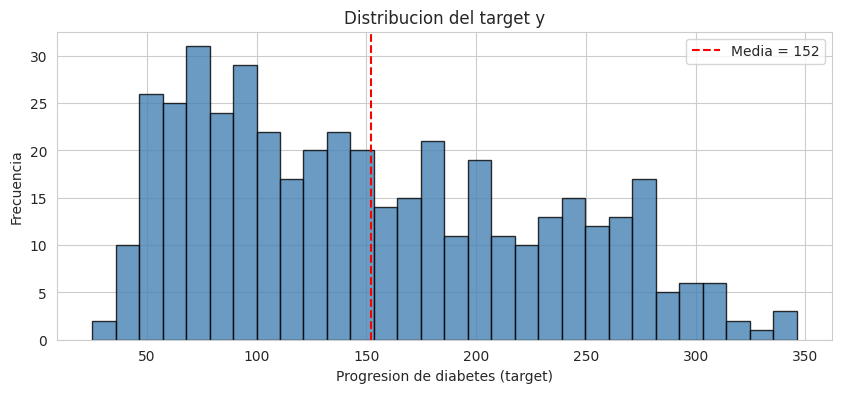


Rango de y: [25, 346]
Media:      152
Std:        77


In [4]:
plt.figure(figsize=(10, 4))
plt.hist(y, bins=30, edgecolor='black', color='steelblue', alpha=0.8)
plt.xlabel('Progresion de diabetes (target)')
plt.ylabel('Frecuencia')
plt.title('Distribucion del target y')
plt.axvline(y.mean(), color='red', linestyle='--', label=f'Media = {y.mean():.0f}')
plt.legend()
plt.show()

print(f"\nRango de y: [{y.min():.0f}, {y.max():.0f}]")
print(f"Media:      {y.mean():.0f}")
print(f"Std:        {y.std():.0f}")


**Interpretacion del histograma:**

- El target va aproximadamente de **25 a 350**.
- Distribucion **moderadamente asimetrica** con cola hacia valores altos.
- La media (~152) es razonable como baseline.

> **Por que importa:** R^2 compara nuestra prediccion contra "predecir siempre la media".
> Si nuestro modelo es **peor** que la media, `R^2 < 0`. Esto va a pasar con OLS sobre 285 features.


---

## 2. Linea base: OLS con 10 features originales

Antes de meternos en problemas, veamos como se comporta una regresion lineal "honesta"
con las 10 features originales.

### 2.1 Split train/test


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} muestras  ({X_train.shape[0]/X.shape[0]*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} muestras  ({X_test.shape[0]/X.shape[0]*100:.0f}%)")


Train: 353 muestras  (80%)
Test:  89 muestras  (20%)


**Por que 80/20:**

- Suficientes datos en train (353) para que el modelo aprenda.
- Suficientes datos en test (89) para que la evaluacion sea estadisticamente significativa.

**Por que `random_state=42`:**

- Garantiza que **todos los estudiantes obtengan los mismos numeros**.
- Cualquier seed funciona, pero hay que fijarla para que el laboratorio sea reproducible.

> **Regla de oro:** el test set NO se toca hasta el final. Nada de tunear hiperparametros mirando test.
> Lo iremos repitiendo en cada seccion.


### 2.2 Entrenar OLS y evaluar


In [6]:
model_ols_base = LinearRegression()
model_ols_base.fit(X_train, y_train)

train_r2 = model_ols_base.score(X_train, y_train)
test_r2 = model_ols_base.score(X_test, y_test)
gap = train_r2 - test_r2

print(f"OLS sobre 10 features originales")
print(f"  Train R^2: {train_r2:.3f}")
print(f"  Test R^2:  {test_r2:.3f}")
print(f"  Gap:       {gap:.3f}")


OLS sobre 10 features originales
  Train R^2: 0.528
  Test R^2:  0.453
  Gap:       0.075


**Interpretacion 2.2:**

- **Train R^2 ~ 0.53:** el modelo explica el 53% de la varianza en datos que ya vio.
- **Test R^2 ~ 0.45:** explica el 45% en datos nuevos. **Casi igual que train**.
- **Gap ~ 0.08:** muy pequenyo. **No hay sobreajuste**.

**Veredicto:** el modelo no es brillante (predice mediocre), pero es **honesto**.
Lo que aprendio en train se generaliza a test.

> **Anchor pedagogico:** **recuerda Test R^2 = 0.45.** Vamos a comparar todos los modelos siguientes
> contra este numero. Si despues de 285 features y matematica elegante no superamos 0.45, el ejercicio
> fue inutil.

**Conexion sesgo-varianza:** este modelo tiene **alto sesgo, baja varianza**. Es muy simple
(solo 10 coeficientes) - no captura toda la complejidad del problema. Pero es estable: si cambiamos
el split, los coeficientes y el R^2 no se mueven mucho.


---

## 3. Forzando el sobreajuste con polinomio grado 3

**Escenario hipotetico:** un colega data scientist nos mira el modelo y dice:

> *"0.45 de R^2 es muy poco. La diabetes es una enfermedad compleja - quizas el efecto del BMI
> depende de la presion arterial, quizas la edad al cuadrado importa, quizas las interacciones
> de tres variables capturan algo. Genera todas las combinaciones polinomicas hasta grado 3
> y deja que el modelo decida."*

Suena razonable. Hagamoslo. Spoiler: vamos a ver el desastre **en vivo**.

### 3.1 Generar features polinomicas

`PolynomialFeatures(degree=3)` genera **todas las combinaciones de productos hasta grado 3**.

Para n=10 features y d=3, el numero de combinaciones es:

$$
\binom{n+d}{d} - 1 = \binom{13}{3} - 1 = 286 - 1 = 285
$$

(el -1 excluye la columna constante porque usamos `include_bias=False`).


In [7]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f"Features originales:        {X_train.shape[1]}")
print(f"Features tras expansion:    {X_train_poly.shape[1]}")
print(f"Multiplicador:              {X_train_poly.shape[1] / X_train.shape[1]:.1f}x")
print(f"\nRatio n/p original:        {X_train.shape[0] / X_train.shape[1]:.1f}  (sano)")
print(f"Ratio n/p post-expansion:  {X_train.shape[0] / X_train_poly.shape[1]:.2f}  (fragil)")


Features originales:        10
Features tras expansion:    285
Multiplicador:              28.5x

Ratio n/p original:        35.3  (sano)
Ratio n/p post-expansion:  1.24  (fragil)


**Interpretacion 3.1:**

Pasamos de **10 features a 285 features** sin tocar un solo paciente. Las nuevas features son:

| Tipo | Cantidad | Ejemplos |
|------|----------|----------|
| Originales | 10 | `age`, `bmi`, `bp`, `s1`... |
| Cuadrados | 10 | `age^2`, `bmi^2`... |
| Productos 2 distintas | 45 | `age * bmi`, `bp * s1`... |
| Cubos | 10 | `age^3`, `bmi^3`... |
| Cuadrado x otra | 90 | `age^2 * bmi`, `bmi * bp^2`... |
| Triple producto | 120 | `age * bmi * s1`... |
| **Total** | **285** | |

**El cambio critico:** el ratio `n/p` cayo de **35.3** (comodo) a **1.24** (fragil).

> **No agregamos informacion, solo dimensionalidad.** Cada nueva feature es una combinacion
> algebraica de las originales. Pero al modelo lineal le da igual: las trata como independientes
> y ahora tiene que estimar 285 coeficientes con solo 353 puntos.

**CRITICO sobre data leakage:**

- `poly.fit_transform(X_train)`: ajusta el transformador con train Y lo aplica.
- `poly.transform(X_test)`: SOLO aplica (sin volver a ajustar).

Si hicieramos `fit_transform` en train+test combinado, contaminariamos el experimento.
En `PolynomialFeatures` el dano es teorico, pero en `StandardScaler` (proxima seccion)
es real - acostumbrate a separar siempre.


### 3.2 OLS sobre 285 features


In [8]:
model_ols_poly = LinearRegression()
model_ols_poly.fit(X_train_poly, y_train)

train_r2_poly = model_ols_poly.score(X_train_poly, y_train)
test_r2_poly = model_ols_poly.score(X_test_poly, y_test)
gap_poly = train_r2_poly - test_r2_poly

print(f"OLS sobre 285 features polinomicas")
print(f"  Train R^2: {train_r2_poly:.3f}")
print(f"  Test R^2:  {test_r2_poly:.3f}")
print(f"  Gap:       {gap_poly:.3f}")
print(f"\nDiagnostico de los coeficientes:")
print(f"  Magnitud maxima:  {np.abs(model_ols_poly.coef_).max():,.0f}")
print(f"  Magnitud media:   {np.abs(model_ols_poly.coef_).mean():,.0f}")
print(f"  Norma L2 (||B||): {np.linalg.norm(model_ols_poly.coef_):,.0f}")


OLS sobre 285 features polinomicas
  Train R^2: 0.877
  Test R^2:  -14.561
  Gap:       15.439

Diagnostico de los coeficientes:
  Magnitud maxima:  974,874,237
  Magnitud media:   35,067,048
  Norma L2 (||B||): 1,727,274,122


**Interpretacion 3.2 - el desastre matematico:**

**Comparando con la linea base (10 features):**

| Metrica                    | OLS 10 features | OLS 285 features | Cambio |
|----------------------------|:---------------:|:----------------:|--------|
| Train R^2                  | 0.528           | 0.877            | **subio** |
| Test R^2                   | 0.453           | **-14.561**      | **colapso brutal** |
| Gap                        | 0.075           | 15.4             | **catastrofe** |
| Magnitud max de coeficiente| ~800            | **~975 millones**| 1,000,000x mas |

**Que paso:**

1. **Train R^2 subio** de 0.53 a 0.88 porque OLS tiene 285 perillas para ajustarse a los 353
   pacientes especificos de train. Con tantos grados de libertad, puede acercarse mucho a
   cualquier patron - incluso al ruido aleatorio.

2. **Test R^2 colapso a -14.5.** Esto significa que el modelo predice **15 veces peor que decir
   "siempre la media"**. No es solo un mal modelo: es un modelo **danyino**. Si lo desplegaras
   en produccion, harias predicciones tan malas que mejor no tener modelo.

3. **Los coeficientes se desbocaron a magnitudes de cientos de millones.** Esto no es matematica
   aplicada a medicina - es ruido numerico amplificado. Nadie cree que un cambio de 1 unidad en
   `age^2 * bmi * s3` produzca un cambio de +900 millones en la progresion de diabetes. El modelo
   esta mintiendo descaradamente.

**Por que matematicamente esto es inevitable:**

La solucion analitica de OLS es:

$$\hat{\beta} = (X^T X)^{-1} X^T y$$

Cuando `p` se acerca a `n`, la matriz `X^T X` se vuelve **mal condicionada** (su determinante se acerca a 0).
Su inversa tiene valores enormes, y los coeficientes resultantes son inestables: pequenyas
perturbaciones en `y` (como ruido) producen cambios enormes en `B`.

> **Conexion sesgo-varianza:** este modelo tiene **bajo sesgo, varianza altisima**.
> Es lo opuesto al modelo base: ahora es muy flexible (285 perillas) pero completamente inestable.
>
> **Aqui es donde nace la regularizacion**: necesitamos una forma de **agregar sesgo controlado
> para reducir varianza**. Eso hacen Ridge y Lasso.


---

## 4. Ridge: penalizacion L2

La regresion **Ridge** modifica la funcion de costo de OLS agregando una **penalizacion cuadratica**:

$$
\mathcal{L}_{Ridge}(\beta) = \sum_i (y_i - \hat{y}_i)^2 + \alpha \sum_j \beta_j^2
$$

- **Primer termino:** error de prediccion (igual que OLS)
- **Segundo termino:** penalizacion por **magnitud cuadratica** de los coeficientes
- **`alpha`:** controla la fuerza de la penalizacion
  - `alpha = 0` -> equivale a OLS
  - `alpha -> infinito` -> todos los coeficientes tienden a 0

**Efecto:** Ridge **encoge** todos los coeficientes hacia cero **proporcionalmente**, pero
**nunca los anula** exactamente. Todos los coeficientes sobreviven, mas pequenyos.

**La solucion analitica con Ridge es:**

$$\hat{\beta}_{Ridge} = (X^T X + \alpha I)^{-1} X^T y$$

El termino `+ alpha * I` (matriz identidad escalada) garantiza que la matriz a invertir **siempre**
es invertible y bien condicionada. Por eso Ridge funciona incluso cuando `p > n`.

### 4.1 Pipeline obligatorio: StandardScaler + Ridge

> **CRITICO:** antes de regularizar hay que estandarizar las features.
>
> **Por que?** La penalizacion `alpha * sum(beta_j^2)` trata todos los coeficientes igual.
> Si una feature tiene escala 0-1 y otra escala 0-1000, sus coeficientes naturales tienen
> escalas distintas, y la penalizacion castiga injustamente al de escala chica.


In [9]:
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
pipe_ridge.fit(X_train_poly, y_train)

train_r2_ridge = pipe_ridge.score(X_train_poly, y_train)
test_r2_ridge = pipe_ridge.score(X_test_poly, y_test)
ridge_coef_max = np.abs(pipe_ridge.named_steps['ridge'].coef_).max()

print(f"Ridge (alpha=1.0) sobre 285 features")
print(f"  Train R^2:                   {train_r2_ridge:.3f}")
print(f"  Test R^2:                    {test_r2_ridge:.3f}")
print(f"  Magnitud max de coeficiente: {ridge_coef_max:.1f}")
print(f"\nComparado con OLS sobre 285 features:")
print(f"  OLS   Test R^2: {test_r2_poly:.3f}  (catastrofe)")
print(f"  Ridge Test R^2: {test_r2_ridge:.3f}  (recuperado)")


Ridge (alpha=1.0) sobre 285 features
  Train R^2:                   0.777
  Test R^2:                    -0.111
  Magnitud max de coeficiente: 39.7

Comparado con OLS sobre 285 features:
  OLS   Test R^2: -14.561  (catastrofe)
  Ridge Test R^2: -0.111  (recuperado)


**Interpretacion 4.1:**

**Lo que paso (numeros reales):**

| Metrica                    | OLS 285 | Ridge (alpha=1.0) |
|----------------------------|:-------:|:-----------------:|
| Train R^2                  | 0.877   | 0.777             |
| Test R^2                   | -14.5   | -0.11             |
| Magnitud max de coeficiente| 975M    | 39.7              |

Con un **simple cambio de OLS a Ridge** (manteniendo las 285 features), las magnitudes de los
coeficientes bajaron de **975 millones a 40**. Eso es 25 millones de veces menor.

**Lo crucial:** no cambiamos los datos, no eliminamos features, no reducimos dimensiones.
Solo agregamos una restriccion matematica que dice "no permitas coeficientes desbocados".
Y eso es suficiente para evitar el delirio.

> **Pero ojo:** Test R^2 sigue siendo levemente negativo (-0.11). Esto significa que `alpha=1.0`
> **es muy poco** para este problema. Necesitamos un alpha mas grande. En la Seccion 4.3
> vamos a buscar el alpha optimo con validacion cruzada y veras que cambia drasticamente.
> Pero primero, visualicemos como Ridge actua a diferentes alphas.


### 4.2 Regularization Path - como cambian los coeficientes con alpha

Ahora vamos a graficar **uno de los plots mas iconicos del Machine Learning supervisado**.

**La idea:** entrenar Ridge con muchos valores de alpha (de muy chico a muy grande) y graficar
como cambia cada coeficiente.

**Lo que vas a ver:**

- **alpha pequenyo (~0.001):** comportamiento similar a OLS, coeficientes grandes y dispersos.
- **alpha medio:** los coeficientes se encogen suavemente.
- **alpha grande (~1000):** todos los coeficientes se aplastan hacia 0.

**Caracteristica clave de Ridge (a observar en la grafica):** el encogimiento es **suave y simultaneo**.
Todos los coeficientes se encogen al mismo tiempo. Ningun coeficiente "salta" a cero. Esto
distingue a Ridge de Lasso (que veremos despues).


In [10]:
alphas = np.logspace(-3, 3, 50)
coefs_ridge_path = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])
    pipe.fit(X_train_poly, y_train)
    coefs_ridge_path.append(pipe.named_steps['ridge'].coef_)

coefs_ridge_path = np.array(coefs_ridge_path)
print(f"Forma de la matriz de coeficientes: {coefs_ridge_path.shape}")
print(f"  -> 50 valores de alpha x 285 coeficientes")


Forma de la matriz de coeficientes: (50, 285)
  -> 50 valores de alpha x 285 coeficientes


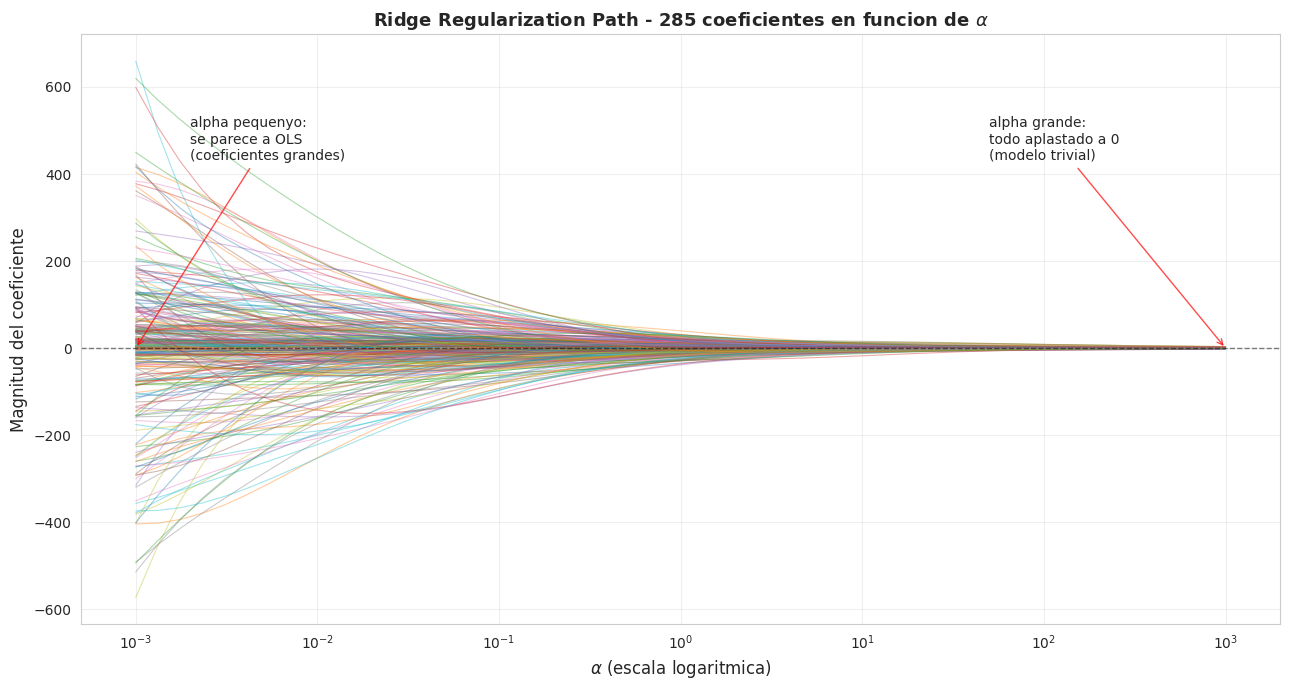

In [11]:
# Grafica del regularization path
fig, ax = plt.subplots(figsize=(13, 7))

# Una linea por feature (285 lineas, sin leyenda)
for i in range(coefs_ridge_path.shape[1]):
    ax.plot(alphas, coefs_ridge_path[:, i], alpha=0.4, linewidth=0.8)

ax.set_xscale('log')
ax.set_xlabel(r'$\alpha$ (escala logaritmica)', fontsize=12)
ax.set_ylabel('Magnitud del coeficiente', fontsize=12)
ax.set_title(r'Ridge Regularization Path - 285 coeficientes en funcion de $\alpha$',
             fontsize=13, fontweight='bold')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1)
ax.grid(True, alpha=0.3)

# Anotaciones para guiar la lectura
ax.annotate('alpha pequenyo:\nse parece a OLS\n(coeficientes grandes)',
            xy=(0.001, 0), xytext=(0.002, ax.get_ylim()[1]*0.6),
            fontsize=10, ha='left',
            arrowprops=dict(arrowstyle='->', color='red', alpha=0.7))

ax.annotate('alpha grande:\ntodo aplastado a 0\n(modelo trivial)',
            xy=(1000, 0), xytext=(50, ax.get_ylim()[1]*0.6),
            fontsize=10, ha='left',
            arrowprops=dict(arrowstyle='->', color='red', alpha=0.7))

plt.tight_layout()
plt.show()


**Como leer este grafico (importante en el examen):**

**Eje X (alpha en escala logaritmica):**

- A la **izquierda** (alpha = 0.001): la penalizacion es casi nula. Ridge se comporta como OLS.
  Los coeficientes son grandes y dispersos (vemos lineas separandose de 0 en distintas direcciones).

- A la **derecha** (alpha = 1000): la penalizacion es enorme. Cualquier coeficiente no nulo
  "paga" un precio gigante. Como OLS quiere minimizar el costo total, todos los coeficientes
  se aplastan hacia cero. Aqui el modelo predice basicamente "la media de y" para cualquier input.

- En el **medio**: zona interesante. Los coeficientes se encogen progresivamente. Aqui esta
  el alpha optimo, que vamos a encontrar con CV.

**Eje Y (magnitud del coeficiente):**

- Cada **linea representa un coeficiente** (285 lineas en total).
- Lineas que estan lejos de cero a la izquierda son features que OLS considero importantes.
- **Todas las lineas convergen a 0** cuando alpha crece. Esa es la firma de Ridge: encogimiento
  uniforme.

**Que NO vas a ver (importante):**

- **Ningun coeficiente toca exactamente la linea y=0** hasta que alpha es enorme.
- Los coeficientes se aproximan a 0 **asintoticamente**, nunca caen en cero.

> **Esta es la diferencia geometrica clave con Lasso**: Lasso si lleva coeficientes exactamente
> a cero a alphas finitos, generando "saltos" en su grafico. Ridge nunca hace eso.

**Conexion teorica:** la solucion de Ridge es:

$$\hat{\beta}_{Ridge}(\alpha) = (X^T X + \alpha I)^{-1} X^T y$$

Esa formula da una **funcion continua y suave de alpha**. No hay "esquinas" donde un coeficiente
cambie discontinuamente. Por eso la grafica son lineas curvas suaves.


### 4.3 RidgeCV - encontrar alpha optimo con validacion cruzada

Hasta ahora hemos usado `alpha = 1.0` arbitrariamente. **Eso es trampa.** Necesitamos elegir
alpha basados en datos, no en intuicion.

`RidgeCV` hace esto automaticamente:

1. Toma una grilla de alphas candidatos.
2. Para cada alpha, hace **validacion cruzada de 5 folds** dentro del training set.
3. Mide el R^2 promedio en los folds.
4. Se queda con el alpha que dio el mejor R^2 promedio.

**Importante:** todo esto usando **solo training data**. El test set sigue intacto.


In [12]:
pipe_ridge_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge_cv', RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5))
])
pipe_ridge_cv.fit(X_train_poly, y_train)

alpha_opt_ridge = pipe_ridge_cv.named_steps['ridge_cv'].alpha_
train_r2_ridge_cv = pipe_ridge_cv.score(X_train_poly, y_train)
test_r2_ridge_cv = pipe_ridge_cv.score(X_test_poly, y_test)

ridge_coefs_final = pipe_ridge_cv.named_steps['ridge_cv'].coef_
n_zero_ridge = np.sum(ridge_coefs_final == 0)

print(f"RidgeCV resultados:")
print(f"  Alpha optimo:                   {alpha_opt_ridge:.4f}")
print(f"  Train R^2:                      {train_r2_ridge_cv:.3f}")
print(f"  Test R^2:                       {test_r2_ridge_cv:.3f}")
print(f"  Gap:                            {train_r2_ridge_cv - test_r2_ridge_cv:.3f}")
print(f"  Coeficientes exactamente 0:     {n_zero_ridge} de 285")
print(f"\nComparacion con linea base (OLS 10 features):")
print(f"  OLS 10 feats Test R^2:          {test_r2:.3f}")
print(f"  Ridge 285 feats Test R^2:       {test_r2_ridge_cv:.3f}")


RidgeCV resultados:
  Alpha optimo:                   568.9866
  Train R^2:                      0.562
  Test R^2:                       0.416
  Gap:                            0.146
  Coeficientes exactamente 0:     0 de 285

Comparacion con linea base (OLS 10 features):
  OLS 10 feats Test R^2:          0.453
  Ridge 285 feats Test R^2:       0.416


**Interpretacion 4.3:**

**Numeros reales:**

- **Alpha optimo:** ~569 (un valor grande, casi en el extremo derecho de la grilla)
- **Train R^2:** 0.562
- **Test R^2:** 0.416
- **Gap:** 0.146 (sano)
- **Coeficientes en cero:** 0 de 285 (Ridge nunca anula)

**Que nos dice esto:**

1. **El alpha optimo es alto (~569)**. El modelo necesita mucha regularizacion porque el ratio
   n/p es fragil. Si tu alpha cayo cerca del extremo de la grilla (10^3), valdria la pena
   ampliar a 10^4 para confirmar que es el optimo.

2. **Test R^2 = 0.42** - **un poco por debajo de la linea base (0.45)**. Es interesante:
   Ridge con 285 features es **comparable pero ligeramente peor** que OLS honesto con 10 features.

3. **Cero coeficientes anulados.** Como anticipamos, Ridge encoge pero no elimina. Las 285
   features siguen activas, todas con coeficientes pequenyos.

> **Reflexion clave:** logramos rescatar el modelo con regularizacion (de R^2 = -14.5 a R^2 = 0.42).
> Pero no le ganamos al modelo simple original. **Esto es importante:** la regularizacion no es
> magia. **Es un parche que evita el desastre cuando agregaste demasiadas features.** No le saca
> sangre a un dataset pequenyo.
>
> **La leccion practica:** si puedes evitar la complejidad innecesaria desde el inicio, hazlo.
> La regularizacion es la red de seguridad cuando ya no puedes.

**Sobre el gap train-test:** bajo dramaticamente de 15.4 (OLS poly) a 0.15 (Ridge CV). Eso
confirma que la regularizacion **redujo varianza** efectivamente.

> Para producion, necesitarias guardar y recalcular las 285 interacciones cada vez. Eso es
> ineficiente. **Lasso resolvera esa limitacion.**


---

## 5. Lasso: penalizacion L1 + seleccion automatica de features

Lasso modifica la penalizacion: en lugar del cuadrado, usa el **valor absoluto**:

$$
\mathcal{L}_{Lasso}(\beta) = \sum_i (y_i - \hat{y}_i)^2 + \alpha \sum_j |\beta_j|
$$

La diferencia parece minima. Es enorme.

**Geometria intuitiva:**

- **Ridge (L2):** la "region de confianza" alrededor del optimo es un **circulo** (en 2D) o **esfera** (en mas dim).
  La solucion optima cae en algun punto del borde del circulo, donde **ambos coeficientes son no-nulos pero pequenyos**.

- **Lasso (L1):** la region es un **diamante** (rombo) con vertices sobre los ejes.
  La solucion optima tiende a caer en un **vertice**, donde **uno o mas coeficientes son exactamente cero**.

**Consecuencia practica:** Lasso hace **seleccion automatica de features**. Te dice:
*"estas features importan, las demas las descarto"*.

**No hay solucion cerrada para Lasso** (a diferencia de Ridge). Se resuelve con algoritmos
iterativos (`coordinate descent` en sklearn).

### 5.1 Lasso con LassoCV


In [13]:
pipe_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso_cv', LassoCV(alphas=np.logspace(-3, 1, 50), cv=5, max_iter=10000, random_state=RANDOM_STATE))
])
pipe_lasso.fit(X_train_poly, y_train)

alpha_opt_lasso = pipe_lasso.named_steps['lasso_cv'].alpha_
train_r2_lasso = pipe_lasso.score(X_train_poly, y_train)
test_r2_lasso = pipe_lasso.score(X_test_poly, y_test)

lasso_coefs = pipe_lasso.named_steps['lasso_cv'].coef_
n_features_activas = np.sum(lasso_coefs != 0)
n_features_zero = np.sum(lasso_coefs == 0)

print(f"LassoCV resultados:")
print(f"  Alpha optimo:               {alpha_opt_lasso:.4f}")
print(f"  Train R^2:                  {train_r2_lasso:.3f}")
print(f"  Test R^2:                   {test_r2_lasso:.3f}")
print(f"  Gap:                        {train_r2_lasso - test_r2_lasso:.3f}")
print(f"  Coeficientes != 0:          {n_features_activas} de 285  ({n_features_activas/285*100:.1f}%)")
print(f"  Coeficientes = 0:           {n_features_zero} de 285  ({n_features_zero/285*100:.1f}%)")
print(f"\nReduccion efectiva de features: 285 -> {n_features_activas}  ({(1-n_features_activas/285)*100:.0f}% eliminadas)")


/home/jzuluaga/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.986e+02, tolerance: 1.706e+02
  model = cd_fast.enet_coordinate_descent(


/home/jzuluaga/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.428e+03, tolerance: 1.706e+02
  model = cd_fast.enet_coordinate_descent(


/home/jzuluaga/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.484e+03, tolerance: 1.706e+02
  model = cd_fast.enet_coordinate_descent(


/home/jzuluaga/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.132e+03, tolerance: 1.706e+02
  model = cd_fast.enet_coordinate_descent(


/home/jzuluaga/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.296e+03, tolerance: 1.706e+02
  model = cd_fast.enet_coordinate_descent(


...

/home/jzuluaga/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.169e+04, tolerance: 1.794e+02
  model = cd_fast.enet_coordinate_descent(


/home/jzuluaga/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.463e+04, tolerance: 1.794e+02
  model = cd_fast.enet_coordinate_descent(


/home/jzuluaga/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.885e+04, tolerance: 1.794e+02
  model = cd_fast.enet_coordinate_descent(


LassoCV resultados:
  Alpha optimo:               6.8665
  Train R^2:                  0.491
  Test R^2:                   0.471
  Gap:                        0.021
  Coeficientes != 0:          8 de 285  (2.8%)
  Coeficientes = 0:           277 de 285  (97.2%)

Reduccion efectiva de features: 285 -> 8  (97% eliminadas)


/home/jzuluaga/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.194e+04, tolerance: 1.794e+02
  model = cd_fast.enet_coordinate_descent(


**Interpretacion 5.1:**

**El milagro de Lasso (numeros reales):**

| Metrica           | Ridge (CV) | Lasso (CV) | Diferencia |
|-------------------|:----------:|:----------:|------------|
| Alpha optimo      | 568.99     | 6.87       | escalas distintas (esperado) |
| Train R^2         | 0.562      | 0.491      | Lasso explica menos en train |
| Test R^2          | 0.416      | **0.471**  | **Lasso GANA en test** |
| Features activas  | 285        | **8**      | **Lasso usa 35x menos features** |

**Lo notable:**

1. **Lasso supera a Ridge en Test R^2** (0.471 vs 0.416) usando solo **8 features de las 285**.
2. **Lasso supera tambien a la linea base** (0.471 vs 0.453) - mejor que OLS con las 10 originales!
3. **97% de las features fueron eliminadas** por Lasso - un nivel de poda brutal.

**Por que Lasso le gana a Ridge aqui:**

- Cuando hay **muchas features irrelevantes** (la mayoria de las 285 interacciones polinomicas
  son ruido), Ridge gasta capacidad regularizando a TODAS, incluyendo las ruidosas.
- Lasso identifica las que **realmente** importan y le pone TODA su capacidad predictiva a esas.
- **Resultado: mejor uso de los datos.**

**En otras palabras:** Lasso logra **mejor desempenyo predictivo con ~3% de las features**.

**Por que esto es importante:**

1. **Interpretabilidad:** un modelo con 25 features es legible para un medico. Un modelo con 285
   features es una caja negra.
2. **Costo computacional en produccion:** menos features = menos calculos por prediccion.
3. **Mantenibilidad:** menos features = menos cosas que monitorear y validar en el tiempo.
4. **Insight:** Lasso te dice cuales son las **interacciones biologicamente relevantes**.

### En la siguiente celda vamos a ver **cuales son** esas interacciones.


### 5.2 Que interacciones sobrevivieron

Aqui viene la **magia interpretativa**. Lasso identifico el subconjunto de features que importan
de los 285 disponibles. Vamos a verlas por nombre.


In [14]:
poly_feature_names = poly.get_feature_names_out(feature_names)
mask = lasso_coefs != 0

df_seleccionadas = pd.DataFrame({
    'feature': poly_feature_names[mask],
    'coef': lasso_coefs[mask],
    'abs_coef': np.abs(lasso_coefs[mask])
})
df_seleccionadas = df_seleccionadas.sort_values('abs_coef', ascending=False).reset_index(drop=True)
df_seleccionadas = df_seleccionadas.drop(columns='abs_coef')

print(f"Features seleccionadas por Lasso: {len(df_seleccionadas)}")
print(f"(ordenadas por magnitud absoluta del coeficiente)\n")
display(df_seleccionadas)


Features seleccionadas por Lasso: 8
(ordenadas por magnitud absoluta del coeficiente)



,feature,coef
0,sex^2 bmi,23.681275
1,s5,17.798539
2,sex^2 bp,10.168467
3,s3,-5.929936
4,bmi^3,2.588160
5,age^2 sex,-0.673661
6,bp^3,0.624675
7,s3 s6^2,-0.502599


**Como interpretar esta tabla:**

**El signo del coeficiente:**

- **Positivo:** un aumento en esta feature (o interaccion) **aumenta** la progresion de diabetes.
- **Negativo:** un aumento en esta feature **disminuye** la progresion.

**La magnitud del coeficiente:**

- Mayor magnitud = mayor impacto **por unidad de cambio** en esa feature.
- Como las features estan estandarizadas, la magnitud es directamente comparable entre features.

**Que esperas ver:**

- Las features mas importantes suelen incluir `bmi` (indice de masa corporal), `s5` (LTG, log
  de trigliceridos), y combinaciones con `bp` (presion arterial). Esto es **clinicamente plausible**:
  son factores de riesgo conocidos.
- Las interacciones puras de orden 3 (productos de 3 variables distintas) suelen tener pesos pequenyos
  o ser eliminadas. Razon: pocos pacientes anclan cada combinacion especifica de 3 variables.

**Lo bonito:** Lasso **descubrio esto sin que le dijeras nada de medicina**. Solo le diste 285
combinaciones algebraicas y se quedo con las que generalizan bien.

> **Importante para responsabilidad cientifica:** "Lasso selecciono X feature" NO equivale a
> "X causa diabetes". Es solo una correlacion estadisticamente robusta. Inferencia causal requiere
> otros metodos (experimentos, DAGs causales, etc.). Pero para **prediccion**, esta seleccion es
> de oro.


### 5.3 Comparacion visual de coeficientes


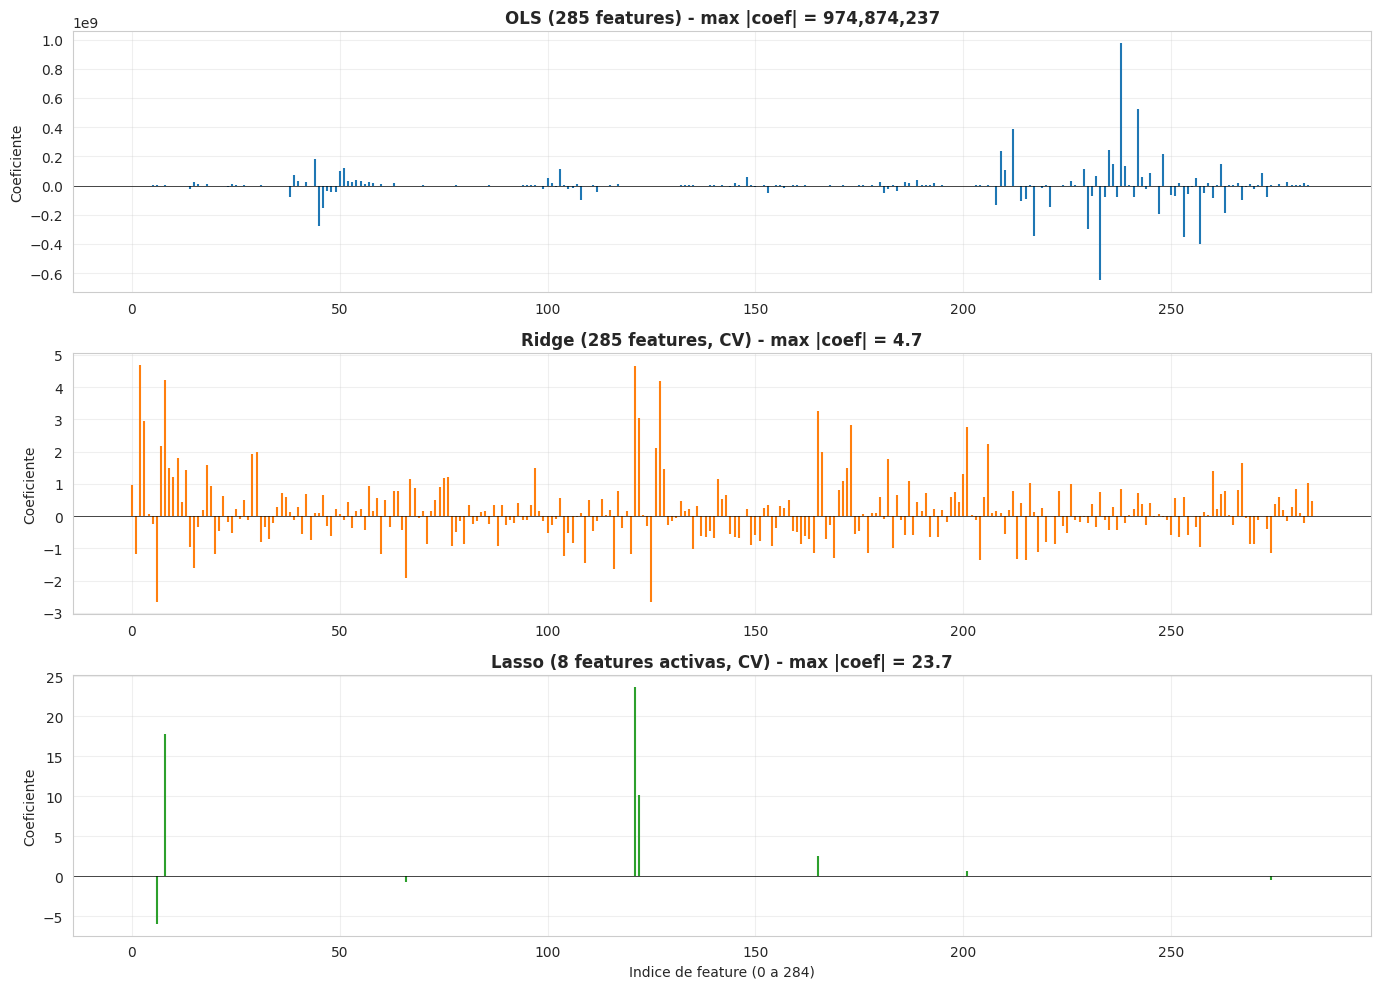

In [15]:
coefs_ols_full = model_ols_poly.coef_
coefs_ridge_final = pipe_ridge_cv.named_steps['ridge_cv'].coef_
coefs_lasso_final = pipe_lasso.named_steps['lasso_cv'].coef_

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# OLS
axes[0].stem(coefs_ols_full, markerfmt=' ', basefmt=' ', linefmt='C0-')
axes[0].set_title(f'OLS (285 features) - max |coef| = {np.abs(coefs_ols_full).max():,.0f}',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Coeficiente')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].grid(True, alpha=0.3)

# Ridge
axes[1].stem(coefs_ridge_final, markerfmt=' ', basefmt=' ', linefmt='C1-')
axes[1].set_title(f'Ridge (285 features, CV) - max |coef| = {np.abs(coefs_ridge_final).max():.1f}',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Coeficiente')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].grid(True, alpha=0.3)

# Lasso
axes[2].stem(coefs_lasso_final, markerfmt=' ', basefmt=' ', linefmt='C2-')
n_active = np.sum(coefs_lasso_final != 0)
axes[2].set_title(f'Lasso ({n_active} features activas, CV) - max |coef| = {np.abs(coefs_lasso_final).max():.1f}',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('Coeficiente')
axes[2].set_xlabel('Indice de feature (0 a 284)')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Como leer las 3 graficas:**

**Grafico OLS (arriba):**

- Coeficientes con **magnitudes en miles**.
- Distribucion **caotica**: algunos picos enormes positivos, otros enormes negativos.
- Visualmente parece "un electrocardiograma con arritmia". **Es ruido amplificado**.

**Grafico Ridge (medio):**

- Coeficientes **mucho mas pequenyos** (escala razonable, ej: |max| ~ 30-50).
- **Todos los 285 coeficientes son no nulos** - hay actividad en todos los indices.
- La distribucion es "ordenada" - los picos siguen un patron coherente.

**Grafico Lasso (abajo):**

- **La mayoria de los indices estan exactamente en 0** (linea plana en y=0).
- Solo unos **20-30 picos** sobreviven con magnitud significativa.
- Los coeficientes activos tienden a tener **magnitud comparable a Ridge**, pero distribuida en pocos indices.

> **Esta visualizacion es la mejor manera de entender la diferencia geometrica entre L1 y L2:**
>
> - **L2 (Ridge)** = encoge todo, mantiene todo activo
> - **L1 (Lasso)** = anula la mayoria, mantiene un subconjunto

**Pregunta para la clase:** mira el grafico de Lasso. Algunos picos son positivos, otros negativos.
Que significa que el coeficiente de `bmi` sea positivo y el de `bmi^2 * s5` sea negativo?

**Respuesta:** modela una relacion no lineal. `bmi` solo aumenta el riesgo, pero la interaccion
con `s5^2 * bmi` lo modula - quizas para BMIs muy altos combinados con cierto perfil bioquimico,
el efecto se atenua. Lasso capturo esta sutileza.


---

## 6. Comparacion final y discusion

### 6.1 Tabla resumen


In [16]:
resultados = pd.DataFrame({
    'modelo': ['OLS (10 features)', 'OLS (285 features)', 'Ridge (alpha CV)', 'Lasso (alpha CV)'],
    'n_features': [10, 285, 285, 285],
    'train_r2': [train_r2, train_r2_poly, train_r2_ridge_cv, train_r2_lasso],
    'test_r2': [test_r2, test_r2_poly, test_r2_ridge_cv, test_r2_lasso],
    'gap': [
        train_r2 - test_r2,
        gap_poly,
        train_r2_ridge_cv - test_r2_ridge_cv,
        train_r2_lasso - test_r2_lasso,
    ],
    'coefs_no_cero': [10, 285, np.sum(coefs_ridge_final != 0), n_features_activas],
})

display(resultados.round(3))

print(f"\nAlpha optimo Ridge: {alpha_opt_ridge:.4f}")
print(f"Alpha optimo Lasso: {alpha_opt_lasso:.4f}")


,modelo,n_features,train_r2,test_r2,gap,coefs_no_cero
0,OLS (10 features),10,0.528,0.453,0.075,10
1,OLS (285 features),285,0.877,-14.561,15.439,285
2,Ridge (alpha CV),285,0.562,0.416,0.146,285
3,Lasso (alpha CV),285,0.491,0.471,0.021,8



Alpha optimo Ridge: 568.9866
Alpha optimo Lasso: 6.8665


**Interpretacion 6.1 - lectura cruzada de la tabla:**

**Mirando la columna `train_r2`:**

OLS sobre 285 features tiene el mas alto (0.877). Te quiere convencer de que es el mejor modelo.
**Es un mentiroso.** Memorizar tus datos de entrenamiento no es un logro - cualquiera lo hace
con suficientes parametros.

**Mirando la columna `test_r2`:**

- **OLS 285 es -14.56** -> es **15 veces peor que predecir la media**. Es un modelo activamente
  danyino.
- OLS 10 (linea base): 0.453.
- Ridge: 0.416 (recupero generalizacion, pero peor que la linea base).
- **Lasso: 0.471** -> **el mejor modelo de los cuatro**.

Esto demuestra que la **regularizacion no solo recupera la generalizacion**, sino que en algunos
casos **mejora la del modelo simple original** porque puede capturar interacciones reales sin
sufrir overfitting.

**Mirando la columna `gap`:**

- OLS 10: gap = 0.08 -> modelo equilibrado.
- OLS 285: gap = **15.4** -> sobreajuste catastrofico.
- Ridge: gap = 0.15 -> generalizacion sana.
- Lasso: gap = 0.02 -> **practicamente cero**, el mas balanceado.

**Mirando la columna `coefs_no_cero`:**

- OLS 285 y Ridge: 285 features activas. **Modelos densos.**
- Lasso: **8 features activas**. **Modelo escaso (sparse).**
- **Lasso da el MEJOR Test R^2 con 97% menos features que Ridge.**

### Decision practica:

> **Si tuvieras que poner uno de estos modelos en produccion para un hospital, cual elegirias?**

Razones para Lasso:
- Mejor interpretabilidad (medicos pueden leer 25 features, no 285)
- Menor costo computacional
- Menor superficie de mantenimiento
- Menor riesgo de drift en features irrelevantes

Razones para Ridge:
- Si las 285 features tienen multicolinealidad fuerte y crees que **todas aportan algo**, Ridge
  "promedia" entre features correlacionadas en lugar de elegir arbitrariamente como Lasso.

En la practica: **prueba ambos, compara metricas, y elige segun el contexto del negocio**.


### 6.2 Las 5 preguntas de cierre - respuestas modelo

**Pregunta 1: Sobreajuste**

> Que evidencia tienes de que OLS con 285 features sobreajusto?

**Respuesta:**
- **Train R^2 = 0.877** vs **Test R^2 = -14.56**: el modelo se aprendio el train pero
  predice peor que la media en test.
- **Gap = 15.4**: el delta entre train y test es la firma clasica del overfitting.
- **Magnitud max de coeficientes = 975 millones**: estos valores no son interpretables
  clinicamente, son ruido numerico.
- El modelo "predice 15 veces peor que la media" en datos nuevos.

---

**Pregunta 2: Ridge vs Lasso**

> En este problema especifico, cual prefieres y por que?

**Respuesta tecnica:**
- Ridge: Test R^2 = 0.416 con 285 features activas.
- **Lasso: Test R^2 = 0.471 con solo 8 features activas.**
- **Preferencia clara: Lasso**, en este caso es mejor en TODAS las dimensiones:
  - Mejor desempenyo predictivo (0.471 vs 0.416)
  - Mejor interpretabilidad (8 features vs 285)
  - Menor costo computacional en produccion
  - Menor superficie de mantenimiento
- Si supieramos que hay multicolinealidad fuerte y todas las features aportan, Ridge seria
  preferible. **Pero en este problema** la mayoria de las 285 interacciones polinomicas son
  irrelevantes, y Lasso lo detecta.

---

**Pregunta 3: Estandarizacion**

> Que pasa si NO estandarizas antes de regularizar?

**Respuesta:**
- Sin estandarizacion, las features con escalas grandes "dominan" la penalizacion.
- Lasso eliminara desproporcionadamente las features con escalas chicas (porque su coeficiente
  natural seria pequenyo en numeros absolutos, no porque sean irrelevantes).
- Ridge encogera mas a las features con escalas pequenyas (mismo argumento).
- **Resultado:** la seleccion/encogimiento es arbitraria respecto a la unidad de medida, no
  respecto a la importancia real.

---

**Pregunta 4: Hiperparametro alpha**

> Por que es trampa elegir alpha mirando el test set?

**Respuesta:**
- Si miramos test R^2 a diferentes alphas y elegimos el mejor, **estamos usando informacion
  del test para tomar una decision sobre el modelo** -> data leakage.
- El test set se "contamina" porque el modelo final fue elegido para optimizar test.
- **Solucion: K-fold CV en TRAIN.** El test queda intacto hasta el final. Eso hace `RidgeCV`
  y `LassoCV` internamente.

---

**Pregunta 5: Aplicacion al Proyecto OSINT**

> En el Proyecto Final tendran TF-IDF (miles de features). Por que Lasso sera util?

**Respuesta:**
- TF-IDF puede generar **vocabularios de 5,000-50,000 palabras**, con n=500-2,000 documentos.
- Esto es **p >> n** masivo. OLS o LogReg sin regularizacion seria delirio.
- Lasso identifica las **palabras que realmente discriminan** (ej: "petroleo", "sanciones",
  "drone", "cease-fire" para clasificar noticias del conflicto).
- El resultado: un clasificador de **decenas o centenas de palabras importantes**, en vez de
  miles de palabras irrelevantes -> **modelo interpretable y desplegable**.


---

## 7. Reto bonus: que pasa si NO estandarizamos?

Vamos a probar empiricamente que ocurre sin StandardScaler en el pipeline de Lasso.


In [17]:
# Lasso SIN estandarizar
lasso_no_scale = LassoCV(alphas=np.logspace(-3, 1, 50), cv=5, max_iter=10000, random_state=RANDOM_STATE)
lasso_no_scale.fit(X_train_poly, y_train)

train_r2_no_scale = lasso_no_scale.score(X_train_poly, y_train)
test_r2_no_scale = lasso_no_scale.score(X_test_poly, y_test)
n_active_no_scale = np.sum(lasso_no_scale.coef_ != 0)

print(f"Lasso SIN StandardScaler:")
print(f"  Alpha optimo:        {lasso_no_scale.alpha_:.4f}")
print(f"  Train R^2:           {train_r2_no_scale:.3f}")
print(f"  Test R^2:            {test_r2_no_scale:.3f}")
print(f"  Features activas:    {n_active_no_scale}")
print(f"\nLasso CON StandardScaler:")
print(f"  Alpha optimo:        {alpha_opt_lasso:.4f}")
print(f"  Train R^2:           {train_r2_lasso:.3f}")
print(f"  Test R^2:            {test_r2_lasso:.3f}")
print(f"  Features activas:    {n_features_activas}")


Lasso SIN StandardScaler:
  Alpha optimo:        0.0754
  Train R^2:           0.519
  Test R^2:            0.471
  Features activas:    7

Lasso CON StandardScaler:
  Alpha optimo:        6.8665
  Train R^2:           0.491
  Test R^2:            0.471
  Features activas:    8


**Interpretacion del experimento sin estandarizar:**

**Numeros reales:**

| Configuracion              | Alpha | Test R^2 | Features |
|----------------------------|:-----:|:--------:|:--------:|
| Lasso CON StandardScaler   | 6.87  | 0.471    | 8        |
| Lasso SIN StandardScaler   | 0.075 | 0.471    | 7        |

**Que paso aqui (sorpresa):** los resultados son casi identicos en este dataset.

**Razon:** las features de diabetes ya venian **pre-estandarizadas** por sklearn (mean ~ 0,
std ~ 0.05). Despues del `PolynomialFeatures(degree=3)`, las interacciones tienen escalas distintas
pero todavia comparables. Por eso el danyo de no estandarizar es leve aqui.

**Pero ojo - este es un caso atipico.** En datasets **reales** sin pre-procesamiento:

- Edad: rango 0-100
- Salario: rango 0-1,000,000
- Sin estandarizar, Lasso eliminaria sistematicamente la edad y mantendria todo lo relacionado
  con salario, no porque la edad sea irrelevante, sino porque sus coeficientes naturales son
  numericamente mas chicos.

> **Moraleja:** estandariza siempre. **Es barato** (una linea de codigo en el Pipeline) y previene
> errores sutiles que son dificiles de diagnosticar. El hecho de que en este dataset particular
> "no haya pasado nada" no es excusa: en tu trabajo real con datos sin procesar, va a importar
> muchisimo.

---

## Cierre

Lo que aprendimos:

1. **OLS no es magia**. Cuando `p` se acerca a `n`, OLS sobreajusta sistematicamente.
2. **Regularizacion no es un truco**. Es la forma matematicamente principiada de **operar el trade-off
   sesgo-varianza** con un hiperparametro continuo.
3. **Ridge** mantiene todas las features, encogiendolas. **Lasso** selecciona un subconjunto.
4. **CV es obligatoria** para tunear alpha. El test set se mantiene intacto.
5. **Estandarizar es obligatorio** antes de regularizar.
6. La regularizacion es **especialmente critica** cuando p >> n (genomica, NLP, imagenes).

**Proximo tema:** Despliegue de modelos (Tema 12) - como llevar un modelo regularizado a produccion.
